In [1]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
# or force it:
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

CUDA_VISIBLE_DEVICES: None
cuda available: True
device count: 1
NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
import os
SEED = 67


import gc
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
from datetime import datetime
from scipy import signal

print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("cuda device name:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(SEED)

torch: 2.12.0+cu126
cuda build: 12.6
cuda available: True
cuda device count: 1
cuda device name: NVIDIA GeForce RTX 3070 Laptop GPU
cuda


In [3]:
from pngtojson import points_to_intensity_grid, png_to_xy_intensity, png_to_xy_binary

In [4]:
def load_data(folder_path):
    # Load the data from the specified folder
    data = dict()
    count = 0 
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.png'):
            #intensity_points = png_to_xy_intensity(os.path.join(folder_path, file_name),include_zero=True)
            intensity_points = png_to_xy_binary(os.path.join(folder_path, file_name),include_zero=True)
            intensity_grid = points_to_intensity_grid(intensity_points )
            intensity_df = pd.DataFrame(intensity_grid)
            data[file_name] = intensity_df
            count += 1
    print(f"Loaded {count} images.")
    
    return data

data = load_data("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png")
print (len(data))

first_key, value = next(iter(data.items()))

print(f"ID {first_key}")
print(value.shape)
print(value.head())


In [5]:
#prev_key = first_key
def create_samples(data, list_length=10, min_list_length = 7):
    count = 1 
    data_grouped = list()
    sample_list= list()
    
    
    ttl_cnt = 0 
    keys = sorted(data.keys())
    prev_key = keys[0]

    for key in keys[1:]:
        value = data[key]
        value= torch.from_numpy(value.to_numpy()).float()
        ttl_cnt+=1
        key_time = datetime.strptime(str(key).strip(".png"),"%Y%m%d%H%M")
        prev_key_time = datetime.strptime(str(prev_key).strip(".png"),"%Y%m%d%H%M")
        change = key_time - prev_key_time
        change = int(change.seconds/60)
        #print(f"doing key {key}, with change {change}, cureent length is {len(sample_list)}, with count {count}")
        
    
        if change > 5: # if non continous jump, end sample
            data_grouped.append(sample_list)
            print(f"sample with lenth {len(sample_list)} created due to discontinuation in series, with change {change}")
            sample_list = list()
            sample_list.append(value)
            
            count=1
            
        elif change == 5 and count <list_length: # add value to sample if we arent at the limit
            sample_list.append(value)
            
            #print("appended")
            count += 1 
            
        elif change == 5 and count >= list_length: # shelve sample and start a new sample
            data_grouped.append(sample_list)
           # print(f"sample with lenth {len(sample_list)} created")
            sample_list = list()
            sample_list.append(value)
            
            count=1
        else:
            print("FUCCCKKK YOU FOING HERE" ) # should never reach this
        
        prev_key = key # pass on key information 
        
    #removing samples too short
    filtered=list()
    for idx, item in enumerate(data_grouped):
        length = len(item)

        if length < min_list_length:
            print(f"removed sample {idx} with length {length}")
        else:
            filtered.append(item)

    data_grouped = filtered
    x=list()
    y=list()

    for i in data_grouped:
        length= len(i)
        
        #print(length)
        last = i.pop(length-1)
        length= len(i)
        
        x.append(i)
        y.append(last)
        
    return x,y
            
            


In [6]:
import os
import pandas as pd
from torch.utils.data import Dataset


class radar_dataset(Dataset):
    def __init__(self, folderloc , list_length=10, min_list_length = 10):
        min_list_length = list_length
        
        self.data = load_data(folderloc)
        self.x, self.y = create_samples(self.data,  list_length=list_length, min_list_length = min_list_length)
        
        
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.x[idx]
        target = self.y[idx]
        
        sample = torch.stack(sample).unsqueeze(1).float()
        target = torch.tensor(target, dtype=torch.float32)
        return sample, target

In [7]:
sample_size= 4 
dataset= radar_dataset("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png", list_length=sample_size)
split_idx = int(0.8 * len(dataset))


train_dataset = torch.utils.data.Subset(dataset, range(0, split_idx))
test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))

Loaded 3536 images.
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 15
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in se

C:\TEMP\ipykernel_10128\4279119954.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  value= torch.from_numpy(value.to_numpy()).float()


sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10

In [8]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches :{len(train_loader)}")
print(f"Test batches :{len(test_loader)}")

Train samples: 685
Test samples: 172
Train batches :86
Test batches :22


In [9]:
for i in range(len(train_dataset)):
    item = train_dataset[i]

    if item is None:
        print("None found at index:", i)
        break

    x, y = item

    if x is None or y is None:
        print("x or y is None at index:", i)
        break

print("done checking")

done checking


C:\TEMP\ipykernel_10128\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


In [10]:
for inputs, labels in train_loader:
    print("inputs shape:", inputs.shape)
    print("labels shape:", labels.shape)
    break

inputs shape: torch.Size([8, 3, 1, 120, 217])
labels shape: torch.Size([8, 120, 217])


C:\TEMP\ipykernel_10128\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


In [11]:
def train_one_epoch(epoch_index, optimizer, model, loss_fn):
    running_loss = 0 
    last_loss = 0 
    for i , data in enumerate(train_loader):
        inputs, labels= data 
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        layer_output_list = model(inputs)

        outputs = layer_output_list
        
        #if labels.dim() == 3:
         #   labels = labels.unsqueeze(1)  # [batch, 120, 217] -> [batch, 1, 120, 217]
        
        #print(f"label: {labels.shape}")
        #print(f"output: {outputs.shape}")
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_loader) + i + 1
           
            running_loss = 0.
    return last_loss  

In [24]:
#import model
from mode import radar_cnn
from models.convlstm import ConvLSTM
model = ConvLSTM(input_dim=1,
                 hidden_dim=128,
                 kernel_size=(3, 3),
                 num_layers=2,
                 batch_first=True,
                 bias=True,)
model = model.to(device)

In [ ]:
#define loss function
import torch.optim
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
loss_fn = torch.nn.MSELoss()
loss_fn = torch.nn.SmoothL1Loss() # try image diff loss 
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([30.0]).to(device))

In [ ]:


epoch_number = 0
val=[]
train=[]
EPOCHS = 200

best_vloss = 1000000000000000


for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_train_loss = train_one_epoch(epoch_number, optimizer,model,loss_fn)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            layer_output_list = model(vinputs)

            voutputs = layer_output_list
            vloss = loss_fn(voutputs, vlabels.float())
            # [B, T, C, H, W] -> [B, C, H, W]
            running_vloss += vloss

    avg_val_loss = running_vloss / (i + 1)
    print(f'LOSS train {avg_train_loss} valid {avg_val_loss}')
    val.append(avg_val_loss.item())
    train.append(avg_train_loss)

    # Log the running loss averaged per batch
    # for both training and validation


    # Track best performance, and save the model's state
    if avg_val_loss < best_vloss:
        best_vloss = avg_val_loss
        model_path = f'model_best.pkl'
        torch.save(model.state_dict(), model_path,)

    epoch_number += 1

EPOCH 1:


C:\TEMP\ipykernel_10128\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)
c:\Users\Jacobs laptop\rainraingoaway\.venv\Lib\site-packages\torch\nn\modules\loss.py:1074: UserWarning: Using a target size (torch.Size([8, 120, 217])) that is different to the input size (torch.Size([8, 1, 120, 217])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


  batch 10 loss: 0.018900405848398805
  batch 20 loss: 0.01689529442228377
  batch 30 loss: 0.012458066828548909
  batch 40 loss: 0.02178007734473795
  batch 50 loss: 0.018128777551464737
  batch 60 loss: 0.0185322561301291
  batch 70 loss: 0.013644623989239334
  batch 80 loss: 0.019502549339085816


c:\Users\Jacobs laptop\rainraingoaway\.venv\Lib\site-packages\torch\nn\modules\loss.py:1074: UserWarning: Using a target size (torch.Size([5, 120, 217])) that is different to the input size (torch.Size([5, 1, 120, 217])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)
c:\Users\Jacobs laptop\rainraingoaway\.venv\Lib\site-packages\torch\nn\modules\loss.py:1074: UserWarning: Using a target size (torch.Size([4, 120, 217])) that is different to the input size (torch.Size([4, 1, 120, 217])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.smooth_l1_loss(input, target, reduction=self.reduction, beta=self.beta)


LOSS train 0.019502549339085816 valid 0.027759885415434837
EPOCH 2:
  batch 10 loss: 0.01898612417280674
  batch 20 loss: 0.013911064295098186
  batch 30 loss: 0.019560866896063088
  batch 40 loss: 0.016484157415106893
  batch 50 loss: 0.018160768412053586
  batch 60 loss: 0.013344039907678962
  batch 70 loss: 0.013457104098051786
  batch 80 loss: 0.01911070039495826
LOSS train 0.01911070039495826 valid 0.027768878266215324
EPOCH 3:
  batch 10 loss: 0.013069836981594562
  batch 20 loss: 0.012158205616287887
  batch 30 loss: 0.028093233751133085
  batch 40 loss: 0.015991473314352335
  batch 50 loss: 0.01672841594554484
  batch 60 loss: 0.01252846848219633
  batch 70 loss: 0.009850317961536348
  batch 80 loss: 0.0196508358232677
LOSS train 0.0196508358232677 valid 0.027779946103692055
EPOCH 4:
  batch 10 loss: 0.014892500871792436
  batch 20 loss: 0.012384938821196557
  batch 30 loss: 0.018687055818736552
  batch 40 loss: 0.014834454795345665
  batch 50 loss: 0.024644973082467915
  batch

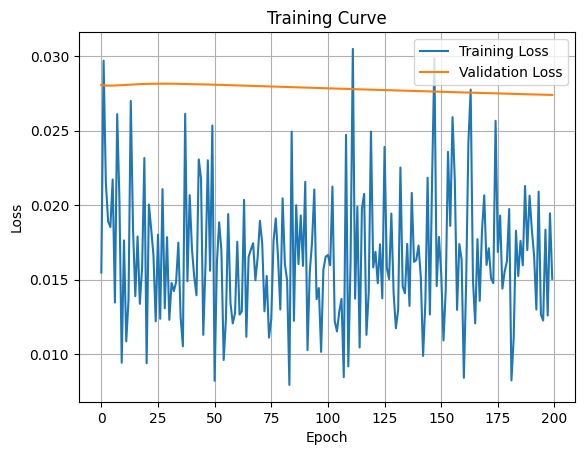

In [15]:
import matplotlib.pyplot as plt

plt.plot(train, label="Training Loss")
plt.plot(val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\TEMP\ipykernel_10128\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


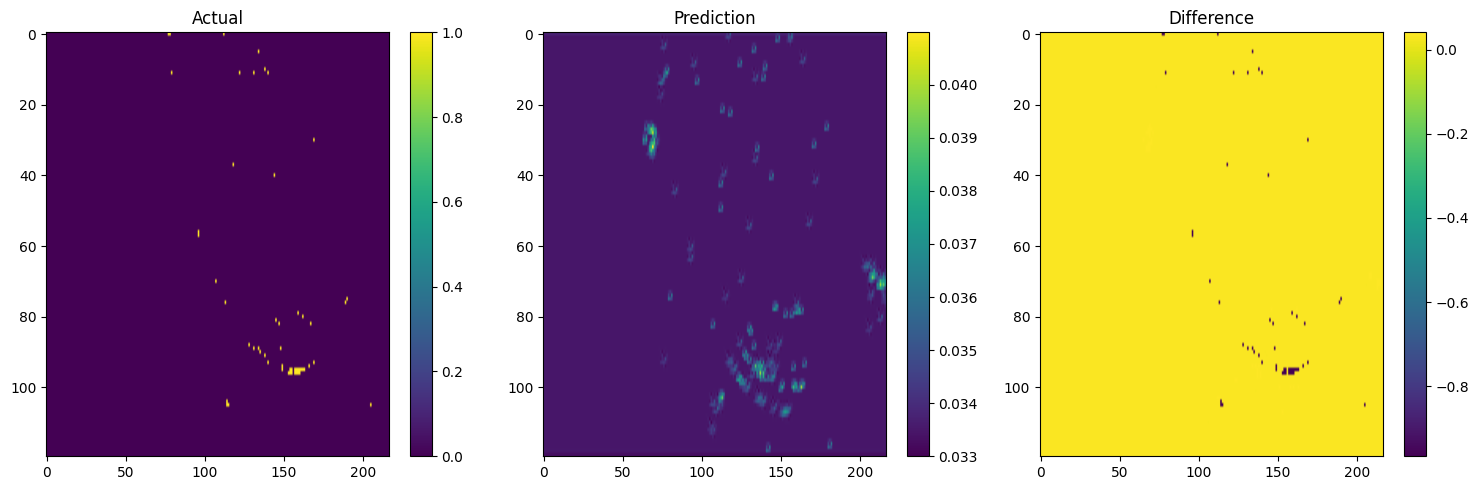

In [16]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(test_loader),4)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

C:\TEMP\ipykernel_10128\3276092173.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


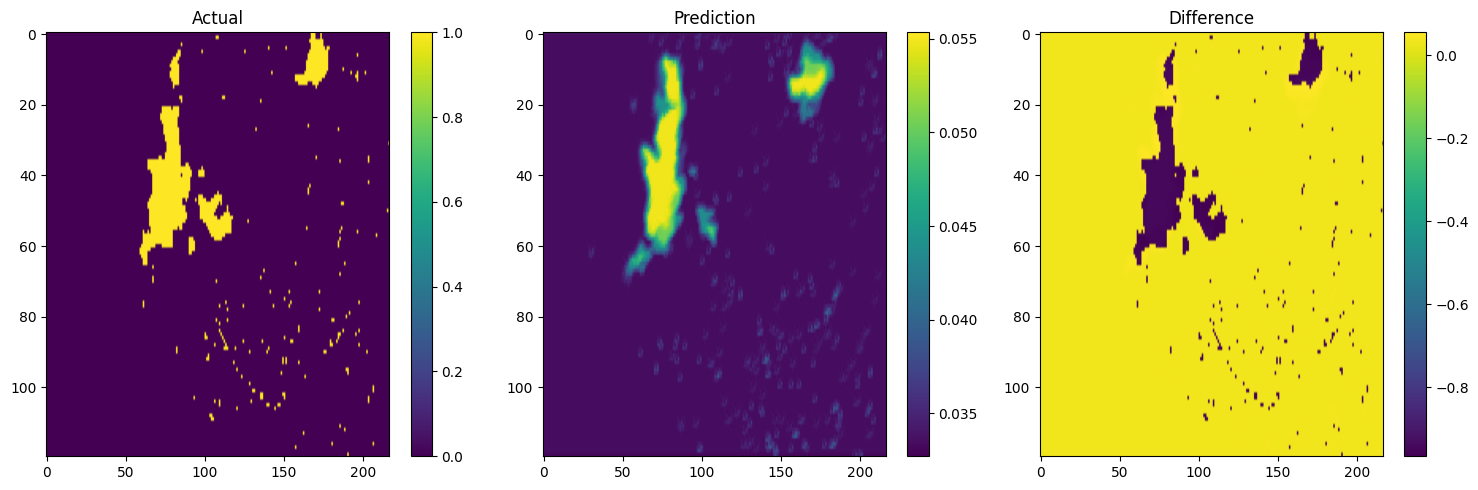

In [17]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(train_loader),3)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()